# Module-2 | Notebook 01 — Dataset Inspection

**Purpose:** Systematically inspect and validate the raw COCO 2014 and RefCOCO datasets  
**Author:** NLP Research Project — Module 2  

---

This notebook is **read-only** with respect to the datasets — it does **not** modify, rename,
move, or overwrite any raw dataset files. All inspection is purely observational.
No preprocessing or merging is performed here.

### Sections
1. Environment Setup
2. COCO 2014 Inspection
3. RefCOCO Inspection
4. COCO ↔ RefCOCO Relationship Verification
5. Summary Table


---
## Part 1 — Environment Setup

Import all required libraries, display version information, and define clean relative paths
from this notebook to the datasets.  
The notebook lives at `module-2/ipynb/` and datasets live at `module-2/datasets/`,
so the relative offset is `../datasets/`.


In [30]:
# Standard Library
import sys
import os
import json
import pickle
import pprint
from pathlib import Path
from collections import Counter, defaultdict

# Third-party
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import IPython

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print('=' * 60)
print('ENVIRONMENT VERSIONS')
print('=' * 60)
print(f'Python     : {sys.version}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'Pillow     : {Image.__version__}')
print(f'IPython    : {IPython.__version__}')
print('=' * 60)


ENVIRONMENT VERSIONS
Python     : 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
NumPy      : 2.3.2
Pandas     : 2.3.1
Matplotlib : 3.10.5
Pillow     : 11.2.1
IPython    : 9.4.0


In [31]:
# ── Path Definitions ──────────────────────────────────────────────────────
# This notebook: module-2/ipynb/01_dataset_inspection.ipynb
# Datasets:      module-2/datasets/
# Outputs:       module-2/outputs/   (for generated files; NOT in datasets/)

NOTEBOOK_DIR  = Path(os.getcwd())          # module-2/ipynb/
MODULE2_DIR   = NOTEBOOK_DIR.parent        # module-2/
DATASETS_DIR  = MODULE2_DIR / 'datasets'   # module-2/datasets/
OUTPUTS_DIR   = MODULE2_DIR / 'outputs'    # module-2/outputs/

# COCO 2014
COCO_DIR        = DATASETS_DIR / 'coco2014'
COCO_TRAIN_DIR  = COCO_DIR / 'train2014'
COCO_ANN_DIR    = COCO_DIR / 'annotations'
COCO_INST_TRAIN = COCO_ANN_DIR / 'instances_train2014.json'
COCO_INST_VAL   = COCO_ANN_DIR / 'instances_val2014.json'
COCO_CAP_TRAIN  = COCO_ANN_DIR / 'captions_train2014.json'
COCO_CAP_VAL    = COCO_ANN_DIR / 'captions_val2014.json'
COCO_KP_TRAIN   = COCO_ANN_DIR / 'person_keypoints_train2014.json'
COCO_KP_VAL     = COCO_ANN_DIR / 'person_keypoints_val2014.json'

# RefCOCO
REFCOCO_DIR    = DATASETS_DIR / 'refcoco' / 'refcoco'
REFCOCO_INST   = REFCOCO_DIR / 'instances.json'
REFCOCO_UNC    = REFCOCO_DIR / 'refs(unc).p'
REFCOCO_GOOGLE = REFCOCO_DIR / 'refs(google).p'

# Create outputs directory (safe — NOT inside datasets/)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print('PATH CONFIGURATION')
print('=' * 60)
print(f'Module-2 root : {MODULE2_DIR}')
print(f'Datasets root : {DATASETS_DIR}')
print(f'Outputs dir   : {OUTPUTS_DIR}')
print()
print('COCO 2014')
print(f'  train2014/       : exists={COCO_TRAIN_DIR.exists()}')
print(f'  annotations/     : exists={COCO_ANN_DIR.exists()}')
print(f'  inst_train.json  : exists={COCO_INST_TRAIN.exists()}')
print(f'  inst_val.json    : exists={COCO_INST_VAL.exists()}')
print(f'  cap_train.json   : exists={COCO_CAP_TRAIN.exists()}')
print(f'  cap_val.json     : exists={COCO_CAP_VAL.exists()}')
print()
print('RefCOCO')
print(f'  instances.json   : exists={REFCOCO_INST.exists()}')
print(f'  refs(unc).p      : exists={REFCOCO_UNC.exists()}')
print(f'  refs(google).p   : exists={REFCOCO_GOOGLE.exists()}')


PATH CONFIGURATION
Module-2 root : d:\NLP-Research\module-2
Datasets root : d:\NLP-Research\module-2\datasets
Outputs dir   : d:\NLP-Research\module-2\outputs

COCO 2014
  train2014/       : exists=True
  annotations/     : exists=True
  inst_train.json  : exists=True
  inst_val.json    : exists=True
  cap_train.json   : exists=True
  cap_val.json     : exists=True

RefCOCO
  instances.json   : exists=True
  refs(unc).p      : exists=True
  refs(google).p   : exists=True


---
## Part 2 — COCO 2014 Inspection

COCO (Common Objects in Context) 2014 is the backbone image dataset used by RefCOCO.  
We inspect: directory structure, image counts, annotation JSON schema, categories,
sample annotations, bounding boxes, and image dimension statistics.


### 2.1 — Directory Structure and File Inventory


In [32]:
def print_dir_tree(root, indent='', max_files=10):
    """Print a clean directory tree with file sizes."""
    items = sorted(root.iterdir())
    dirs  = [p for p in items if p.is_dir()]
    files = [p for p in items if p.is_file()]
    for d in dirs:
        try:
            n = sum(1 for _ in d.iterdir())
        except Exception:
            n = '?'
        print(f'{indent}[DIR]  {d.name}/  ({n} immediate items)')
    for f in files[:max_files]:
        size_mb = f.stat().st_size / (1024 ** 2)
        print(f'{indent}[FILE] {f.name}  ({size_mb:.1f} MB)')
    if len(files) > max_files:
        print(f'{indent}       ... and {len(files) - max_files} more files')

print('COCO 2014 — Directory Tree')
print('=' * 60)
print_dir_tree(COCO_DIR)
print()
print('Annotation files detail:')
for f in sorted(COCO_ANN_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 ** 2)
    print(f'  {f.name:<45} ({size_mb:7.1f} MB)')


COCO 2014 — Directory Tree
[DIR]  annotations/  (6 immediate items)
[DIR]  train2014/  (82783 immediate items)

Annotation files detail:
  captions_train2014.json                       (   63.7 MB)
  captions_val2014.json                         (   30.9 MB)
  instances_train2014.json                      (  317.2 MB)
  instances_val2014.json                        (  153.2 MB)
  person_keypoints_train2014.json               (  162.8 MB)
  person_keypoints_val2014.json                 (   77.9 MB)


### 2.2 — train2014 Image Count and File Extensions


In [33]:
train_files  = list(COCO_TRAIN_DIR.iterdir())
train_images = [f for f in train_files if f.is_file()]
ext_counter  = Counter(f.suffix.lower() for f in train_images)

print(f'Total files in train2014/  : {len(train_images):,}')
print(f'File extensions found      : {dict(ext_counter)}')
print()
print('Sample filenames (first 10):')
for f in sorted(train_images)[:10]:
    print(f'  {f.name}')


Total files in train2014/  : 82,783
File extensions found      : {'.jpg': 82783}

Sample filenames (first 10):
  COCO_train2014_000000000009.jpg
  COCO_train2014_000000000025.jpg
  COCO_train2014_000000000030.jpg
  COCO_train2014_000000000034.jpg
  COCO_train2014_000000000036.jpg
  COCO_train2014_000000000049.jpg
  COCO_train2014_000000000061.jpg
  COCO_train2014_000000000064.jpg
  COCO_train2014_000000000071.jpg
  COCO_train2014_000000000072.jpg


### 2.3 — COCO Annotation JSON Structure (`instances_train2014.json`)

The COCO annotation JSON follows a standard schema with five top-level keys:
- `info` — dataset metadata  
- `licenses` — image license list  
- `images` — list of image records  
- `annotations` — list of object instance annotations  
- `categories` — list of object category definitions  


In [34]:
print('Loading instances_train2014.json  (may take ~10-20 seconds) ...')
with open(COCO_INST_TRAIN, 'r') as f:
    coco_train = json.load(f)
print('Loaded.')
print()

print('Top-level keys:')
for key, val in coco_train.items():
    if isinstance(val, list):
        print(f'  {key!r:<15} ->  list  ({len(val):,} entries)')
    elif isinstance(val, dict):
        print(f'  {key!r:<15} ->  dict  (keys: {list(val.keys())})')
    else:
        print(f'  {key!r:<15} ->  {type(val).__name__}  =  {val}')

print()
print('-- info --')
pprint.pprint(coco_train.get('info', {}))
print()
print('-- licenses (first 3) --')
for lic in coco_train.get('licenses', [])[:3]:
    print(f'  {lic}')


Loading instances_train2014.json  (may take ~10-20 seconds) ...


Loaded.

Top-level keys:
  'info'          ->  dict  (keys: ['description', 'url', 'version', 'year', 'contributor', 'date_created'])
  'images'        ->  list  (82,783 entries)
  'licenses'      ->  list  (8 entries)
  'annotations'   ->  list  (604,907 entries)
  'categories'    ->  list  (80 entries)

-- info --
{'contributor': 'COCO Consortium',
 'date_created': '2017/09/01',
 'description': 'COCO 2014 Dataset',
 'url': 'http://cocodataset.org',
 'version': '1.0',
 'year': 2014}

-- licenses (first 3) --
  {'url': 'http://creativecommons.org/licenses/by-nc-sa/2.0/', 'id': 1, 'name': 'Attribution-NonCommercial-ShareAlike License'}
  {'url': 'http://creativecommons.org/licenses/by-nc/2.0/', 'id': 2, 'name': 'Attribution-NonCommercial License'}
  {'url': 'http://creativecommons.org/licenses/by-nc-nd/2.0/', 'id': 3, 'name': 'Attribution-NonCommercial-NoDerivs License'}


### 2.4 — Images: Count, Fields, and Sample Records


In [35]:
coco_images = coco_train['images']
print(f'Number of images in instances_train2014.json : {len(coco_images):,}')
print()
print('Image record fields:', list(coco_images[0].keys()))
print()
print('Sample image records (first 5):')
for img in coco_images[:5]:
    print(f"  id={img['id']}  |  file={img['file_name']}  |  W={img['width']}  H={img['height']}")


Number of images in instances_train2014.json : 82,783

Image record fields: ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'id']

Sample image records (first 5):
  id=57870  |  file=COCO_train2014_000000057870.jpg  |  W=640  H=480
  id=384029  |  file=COCO_train2014_000000384029.jpg  |  W=640  H=429
  id=222016  |  file=COCO_train2014_000000222016.jpg  |  W=480  H=640
  id=520950  |  file=COCO_train2014_000000520950.jpg  |  W=640  H=427
  id=69675  |  file=COCO_train2014_000000069675.jpg  |  W=640  H=480


### 2.5 — Image Dimensions: Width & Height Statistics


IMAGE DIMENSION STATISTICS
Width  — min=59, max=640, mean=578.0, median=640.0
Height — min=51, max=640, mean=483.6, median=480.0


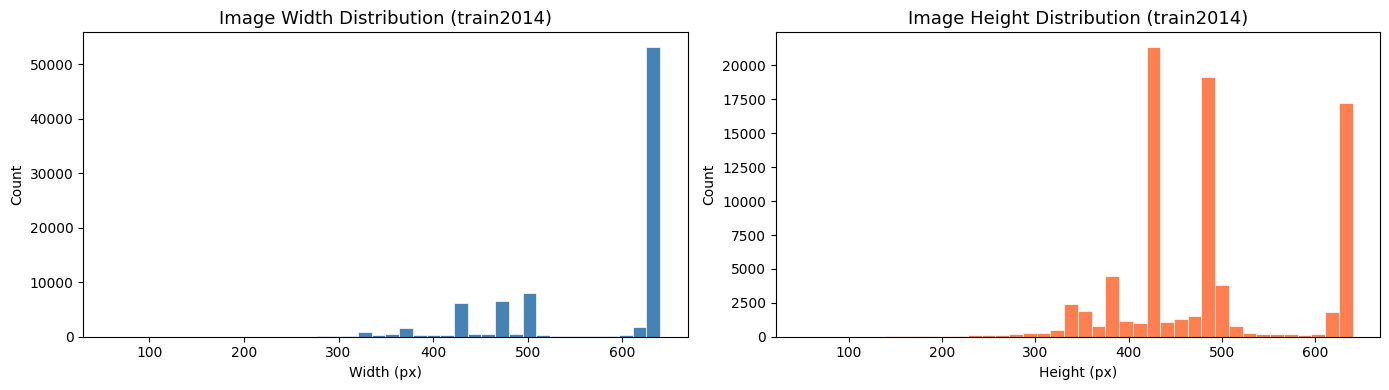

Figure saved -> d:\NLP-Research\module-2\outputs\coco_image_dim_distribution.png


In [36]:
widths  = [img['width']  for img in coco_images]
heights = [img['height'] for img in coco_images]

print('IMAGE DIMENSION STATISTICS')
print('=' * 50)
print(f'Width  — min={min(widths)}, max={max(widths)}, '
      f'mean={np.mean(widths):.1f}, median={np.median(widths):.1f}')
print(f'Height — min={min(heights)}, max={max(heights)}, '
      f'mean={np.mean(heights):.1f}, median={np.median(heights):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(widths,  bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Image Width Distribution (train2014)', fontsize=13)
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Count')
axes[1].hist(heights, bins=40, color='coral',     edgecolor='white', linewidth=0.5)
axes[1].set_title('Image Height Distribution (train2014)', fontsize=13)
axes[1].set_xlabel('Height (px)'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'coco_image_dim_distribution.png', dpi=100)
plt.show()
print(f"Figure saved -> {OUTPUTS_DIR / 'coco_image_dim_distribution.png'}")


### 2.6 — Object Annotations: Count, Fields, and Sample Records

COCO bounding box format: `[x_min, y_min, width, height]` (top-left corner + dimensions)


In [37]:
coco_annotations = coco_train['annotations']
print(f'Total object annotations in train2014 : {len(coco_annotations):,}')
print()
print('Annotation record fields:', list(coco_annotations[0].keys()))
print()
print('Sample annotation records (first 5):')
for ann in coco_annotations[:5]:
    bbox = ann['bbox']  # [x, y, width, height]
    print(f"  ann_id={ann['id']}  image_id={ann['image_id']}  "
          f"cat_id={ann['category_id']}  bbox={bbox}  area={ann['area']:.1f}")


Total object annotations in train2014 : 604,907

Annotation record fields: ['segmentation', 'area', 'iscrowd', 'image_id', 'bbox', 'category_id', 'id']

Sample annotation records (first 5):
  ann_id=86  image_id=480023  cat_id=58  bbox=[116.95, 305.86, 285.3, 266.03]  area=54653.0
  ann_id=89  image_id=50518  cat_id=58  bbox=[245.54, 208.17, 40.14, 19.1]  area=421.5
  ann_id=93  image_id=142589  cat_id=58  bbox=[288.4, 18.07, 211.6, 331.33]  area=53535.3
  ann_id=113  image_id=209263  cat_id=58  bbox=[126.5, 475.24, 77.68, 76.73]  area=3892.4
  ann_id=116  image_id=15307  cat_id=58  bbox=[185.57, 93.4, 219.97, 420.29]  area=72576.2


### 2.7 — Categories: IDs and Names


In [38]:
coco_categories = coco_train['categories']
print(f'Number of categories : {len(coco_categories)}')
print()
print(f"{'ID':>5}  {'SuperCategory':<20}  {'Name'}")
print('-' * 48)
for cat in coco_categories:
    print(f"{cat['id']:>5}  {cat['supercategory']:<20}  {cat['name']}")


Number of categories : 80

   ID  SuperCategory         Name
------------------------------------------------
    1  person                person
    2  vehicle               bicycle
    3  vehicle               car
    4  vehicle               motorcycle
    5  vehicle               airplane
    6  vehicle               bus
    7  vehicle               train
    8  vehicle               truck
    9  vehicle               boat
   10  outdoor               traffic light
   11  outdoor               fire hydrant
   13  outdoor               stop sign
   14  outdoor               parking meter
   15  outdoor               bench
   16  animal                bird
   17  animal                cat
   18  animal                dog
   19  animal                horse
   20  animal                sheep
   21  animal                cow
   22  animal                elephant
   23  animal                bear
   24  animal                zebra
   25  animal                giraffe
   27  accessory    

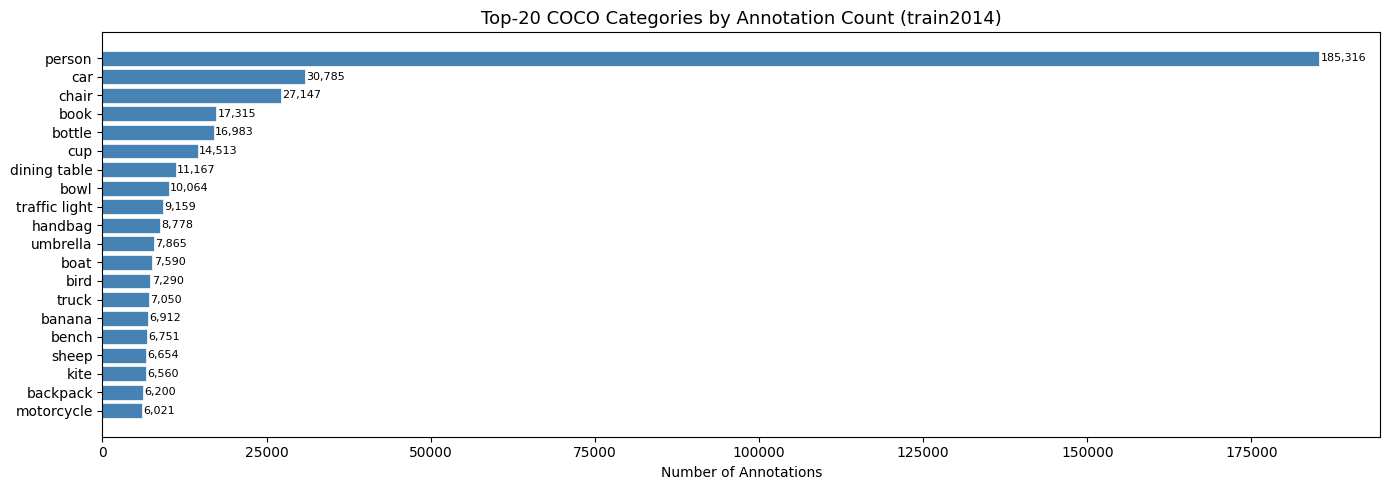

Figure saved -> d:\NLP-Research\module-2\outputs\coco_category_distribution.png


In [39]:
# Annotation count per category — top 20
cat_id_to_name = {cat['id']: cat['name'] for cat in coco_categories}
ann_per_cat    = Counter(ann['category_id'] for ann in coco_annotations)

top20  = ann_per_cat.most_common(20)
names  = [cat_id_to_name[cid] for cid, _ in top20]
counts = [cnt for _, cnt in top20]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(names[::-1], counts[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Annotations')
ax.set_title('Top-20 COCO Categories by Annotation Count (train2014)', fontsize=13)
for bar, cnt in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'coco_category_distribution.png', dpi=100)
plt.show()
print(f"Figure saved -> {OUTPUTS_DIR / 'coco_category_distribution.png'}")


### 2.8 — Sample Bounding Boxes Across Images


In [40]:
# Lookup tables
img_id_to_info = {img['id']: img for img in coco_images}
img_id_to_anns = defaultdict(list)
for ann in coco_annotations:
    img_id_to_anns[ann['image_id']].append(ann)

print('Bounding box format: [x_min, y_min, width, height]')
print()
for img_id in list(img_id_to_anns.keys())[:5]:
    info         = img_id_to_info[img_id]
    anns_for_img = img_id_to_anns[img_id]
    print(f"Image ID={img_id}  file={info['file_name']}  ({info['width']}x{info['height']})")
    for ann in anns_for_img[:3]:
        cat = cat_id_to_name.get(ann['category_id'], 'unknown')
        print(f"  ann_id={ann['id']}  cat={cat:<15}  bbox={ann['bbox']}")
    if len(anns_for_img) > 3:
        print(f'  ... and {len(anns_for_img) - 3} more annotations')
    print()


Bounding box format: [x_min, y_min, width, height]

Image ID=480023  file=COCO_train2014_000000480023.jpg  (480x640)
  ann_id=86  cat=hot dog          bbox=[116.95, 305.86, 285.3, 266.03]
  ann_id=438029  cat=person           bbox=[75.23, 134.7, 203.17, 215.63]
  ann_id=460329  cat=person           bbox=[239.33, 176.98, 110.56, 133.66]
  ... and 9 more annotations

Image ID=50518  file=COCO_train2014_000000050518.jpg  (640x480)
  ann_id=89  cat=hot dog          bbox=[245.54, 208.17, 40.14, 19.1]
  ann_id=123195  cat=dining table     bbox=[33.8, 223.77, 270.43, 228.74]
  ann_id=183682  cat=person           bbox=[214.65, 124.12, 193.08, 341.93]
  ... and 7 more annotations

Image ID=142589  file=COCO_train2014_000000142589.jpg  (500x375)
  ann_id=93  cat=hot dog          bbox=[288.4, 18.07, 211.6, 331.33]
  ann_id=1903296  cat=bowl             bbox=[0.0, 29.05, 262.94, 336.5]

Image ID=209263  file=COCO_train2014_000000209263.jpg  (480x640)
  ann_id=113  cat=hot dog          bbox=[126.5,

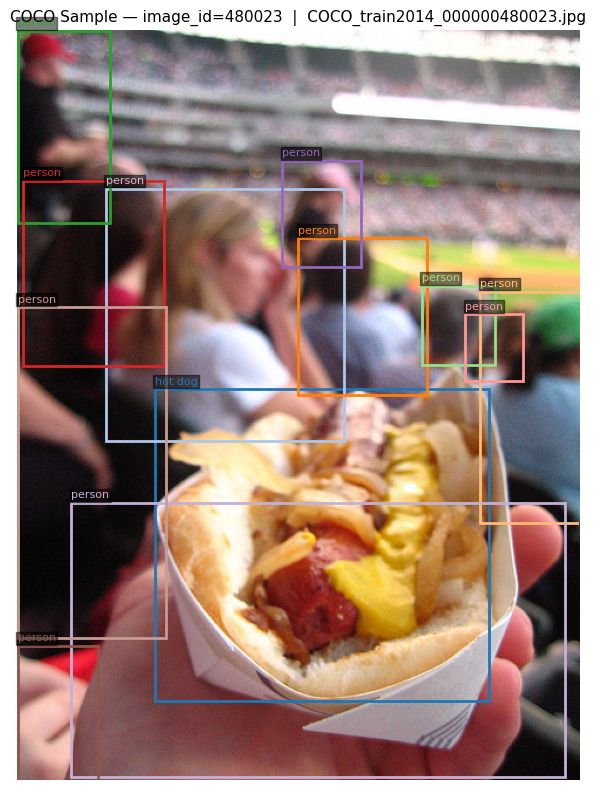

Figure saved -> d:\NLP-Research\module-2\outputs\coco_sample_bbox.png


In [41]:
def find_image_on_disk(file_name, search_dir):
    """Return the Path if the image exists on disk, else None."""
    p = search_dir / file_name
    return p if p.exists() else None


# Find first image that exists on disk
viz_img_id = None
for img_id in img_id_to_anns:
    info = img_id_to_info[img_id]
    if find_image_on_disk(info['file_name'], COCO_TRAIN_DIR) is not None:
        viz_img_id = img_id
        break

if viz_img_id is not None:
    info     = img_id_to_info[viz_img_id]
    img_path = find_image_on_disk(info['file_name'], COCO_TRAIN_DIR)
    anns_viz = img_id_to_anns[viz_img_id]
    img_pil  = Image.open(img_path).convert('RGB')
    fig, ax  = plt.subplots(figsize=(10, 8))
    ax.imshow(img_pil)
    colors = plt.cm.tab20.colors
    for i, ann in enumerate(anns_viz):
        x, y, w, h = ann['bbox']
        color = colors[i % len(colors)]
        ax.add_patch(Rectangle((x, y), w, h, linewidth=2,
                                edgecolor=color, facecolor='none'))
        cat = cat_id_to_name.get(ann['category_id'], '?')
        ax.text(x, y - 4, cat, fontsize=8, color=color,
                bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.set_title(f"COCO Sample — image_id={viz_img_id}  |  {info['file_name']}",
                 fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'coco_sample_bbox.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Figure saved -> {OUTPUTS_DIR / 'coco_sample_bbox.png'}")
else:
    print('No train2014 image files found on disk to visualise.')
    print('(Expected if images are still inside the .zip archive.)')


### 2.9 — Annotations per Image Distribution


ANNOTATIONS PER IMAGE — Statistics
Min      : 1
Max      : 93
Mean     : 7.37
Median   : 4.0
Std dev  : 7.41


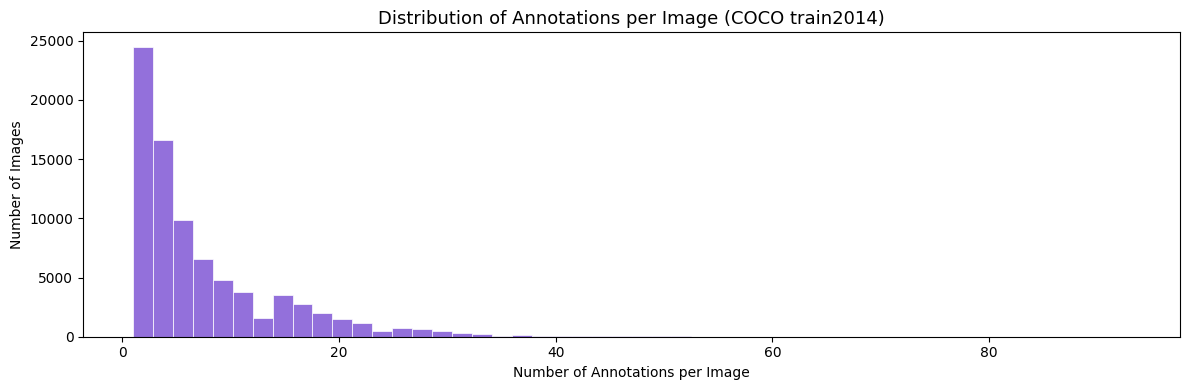

Figure saved -> d:\NLP-Research\module-2\outputs\coco_anns_per_image_dist.png


In [42]:
anns_per_image = [len(v) for v in img_id_to_anns.values()]

print('ANNOTATIONS PER IMAGE — Statistics')
print('=' * 45)
print(f'Min      : {min(anns_per_image)}')
print(f'Max      : {max(anns_per_image)}')
print(f'Mean     : {np.mean(anns_per_image):.2f}')
print(f'Median   : {np.median(anns_per_image):.1f}')
print(f'Std dev  : {np.std(anns_per_image):.2f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(anns_per_image, bins=50, color='mediumpurple',
        edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Annotations per Image')
ax.set_ylabel('Number of Images')
ax.set_title('Distribution of Annotations per Image (COCO train2014)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'coco_anns_per_image_dist.png', dpi=100)
plt.show()
print(f"Figure saved -> {OUTPUTS_DIR / 'coco_anns_per_image_dist.png'}")


---
## Part 3 — RefCOCO Inspection

RefCOCO extends COCO with **natural language referring expressions** that unambiguously
identify a specific object in an image.  
It ships three files:

| File | Description |
|---|---|
| `instances.json` | COCO-formatted object instance annotations (subset) |
| `refs(unc).p` | Referring expressions collected via UNC annotation tool |
| `refs(google).p` | Referring expressions collected via Google annotation tool |

We **do not assume** any structure — each file is loaded and inspected independently.


### 3.1 — `instances.json` Inspection


In [43]:
print('Loading RefCOCO instances.json ...')
with open(REFCOCO_INST, 'r') as f:
    refcoco_inst = json.load(f)
print('Loaded.')
print()

print('Data type         :', type(refcoco_inst).__name__)
print('Top-level keys    :', list(refcoco_inst.keys()))
print()

for key, val in refcoco_inst.items():
    if isinstance(val, list):
        print(f'  {key!r}  ->  list  ({len(val):,} entries)')
        if val and isinstance(val[0], dict):
            print(f'       First entry keys: {list(val[0].keys())}')
    elif isinstance(val, dict):
        print(f'  {key!r}  ->  dict  (keys: {list(val.keys())})')
    else:
        print(f'  {key!r}  ->  {type(val).__name__}  =  {val}')


Loading RefCOCO instances.json ...
Loaded.

Data type         : dict
Top-level keys    : ['info', 'images', 'licenses', 'annotations', 'categories']

  'info'  ->  dict  (keys: ['description', 'url', 'version', 'year', 'contributor', 'date_created'])
  'images'  ->  list  (19,994 entries)
       First entry keys: ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'id']
  'licenses'  ->  list  (8 entries)
       First entry keys: ['url', 'id', 'name']
  'annotations'  ->  list  (196,771 entries)
       First entry keys: ['segmentation', 'area', 'iscrowd', 'image_id', 'bbox', 'category_id', 'id']
  'categories'  ->  list  (80 entries)
       First entry keys: ['supercategory', 'id', 'name']


In [44]:
rc_images = refcoco_inst.get('images', [])
rc_anns   = refcoco_inst.get('annotations', [])
rc_cats   = refcoco_inst.get('categories', [])

# Images
print(f'RefCOCO instances.json — images : {len(rc_images):,}')
if rc_images:
    print('  Fields :', list(rc_images[0].keys()))
    print('  Sample records (first 5):')
    for img in rc_images[:5]:
        print(f"    id={img['id']}  file={img.get('file_name','N/A')}  "
              f"W={img.get('width','?')}  H={img.get('height','?')}")

print()
# Annotations
print(f'RefCOCO instances.json — annotations : {len(rc_anns):,}')
if rc_anns:
    print('  Fields :', list(rc_anns[0].keys()))
    print('  Sample records (first 5):')
    for ann in rc_anns[:5]:
        print(f"    id={ann['id']}  image_id={ann['image_id']}  "
              f"cat_id={ann.get('category_id','?')}  bbox={ann.get('bbox','?')}")

print()
# Categories
print(f'RefCOCO instances.json — categories : {len(rc_cats):,}')
if rc_cats:
    print('  All categories:')
    for cat in rc_cats:
        print(f'    {cat}')


RefCOCO instances.json — images : 19,994
  Fields : ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'id']
  Sample records (first 5):
    id=98304  file=COCO_train2014_000000098304.jpg  W=640  H=424
    id=52461  file=COCO_train2014_000000052461.jpg  W=640  H=484
    id=131074  file=COCO_train2014_000000131074.jpg  W=640  H=428
    id=524291  file=COCO_train2014_000000524291.jpg  W=640  H=426
    id=425988  file=COCO_train2014_000000425988.jpg  W=640  H=498

RefCOCO instances.json — annotations : 196,771
  Fields : ['segmentation', 'area', 'iscrowd', 'image_id', 'bbox', 'category_id', 'id']
  Sample records (first 5):
    id=3007  image_id=98304  cat_id=18  bbox=[263.87, 216.88, 21.13, 15.17]
    id=99893  image_id=98304  cat_id=63  bbox=[71.88, 213.93, 181.97, 199.26]
    id=108703  image_id=98304  cat_id=62  bbox=[334.49, 288.62, 130.02, 130.82]
    id=115415  image_id=98304  cat_id=63  bbox=[398.89, 214.13, 129.7, 76.01]
    id=116865  image_id

In [45]:
rc_image_ids_inst = set(img['id'] for img in rc_images)
rc_ann_ids_inst   = set(ann['id'] for ann in rc_anns)

print(f'Unique image IDs in RefCOCO instances.json : {len(rc_image_ids_inst):,}')
print(f'Unique annotation IDs in RefCOCO instances : {len(rc_ann_ids_inst):,}')
print(f'Sample image IDs (first 10): {sorted(rc_image_ids_inst)[:10]}')
print(f'Sample ann IDs   (first 10): {sorted(rc_ann_ids_inst)[:10]}')


Unique image IDs in RefCOCO instances.json : 19,994
Unique annotation IDs in RefCOCO instances : 196,771
Sample image IDs (first 10): [72, 110, 113, 144, 154, 165, 201, 263, 308, 309]
Sample ann IDs   (first 10): [86, 126, 152, 166, 250, 275, 284, 303, 353, 384]


### 3.2 — `refs(unc).p` Inspection

The `.p` files are Python pickle files. Each reference links a natural language expression
to a specific object in a specific image.


In [46]:
print('Loading refs(unc).p ...')
with open(REFCOCO_UNC, 'rb') as f:
    refs_unc = pickle.load(f, encoding='latin1')
print('Loaded.')
print()

refs_list_unc = refs_unc if isinstance(refs_unc, list) else list(refs_unc.values())

print(f'Data type            : {type(refs_unc).__name__}')
print(f'Number of entries    : {len(refs_list_unc):,}')
print(f'Entry type           : {type(refs_list_unc[0]).__name__}')
print()
print('Fields in each entry :', list(refs_list_unc[0].keys()))


Loading refs(unc).p ...
Loaded.

Data type            : list
Number of entries    : 50,000
Entry type           : dict

Fields in each entry : ['sent_ids', 'file_name', 'ann_id', 'ref_id', 'image_id', 'split', 'sentences', 'category_id']


In [47]:
# Deep-inspect first entry
print('SAMPLE ENTRY — refs(unc).p[0]')
print('=' * 60)
for k, v in refs_list_unc[0].items():
    key_repr = repr(k).ljust(20)
    if isinstance(v, list) and v and isinstance(v[0], dict):
        print(f'  {key_repr} : list of {len(v)} dicts')
        print(f'       first dict keys : {list(v[0].keys())}')
        print(f'       first dict      : {v[0]}')
    elif isinstance(v, list):
        print(f'  {key_repr} : {v}')
    else:
        print(f'  {key_repr} : {v}')


SAMPLE ENTRY — refs(unc).p[0]
  'sent_ids'           : [0, 1, 2]
  'file_name'          : COCO_train2014_000000581857_16.jpg
  'ann_id'             : 1719310
  'ref_id'             : 0
  'image_id'           : 581857
  'split'              : train
  'sentences'          : list of 3 dicts
       first dict keys : ['tokens', 'raw', 'sent_id', 'sent']
       first dict      : {'tokens': ['the', 'lady', 'with', 'the', 'blue', 'shirt'], 'raw': 'THE LADY WITH THE BLUE SHIRT', 'sent_id': 0, 'sent': 'the lady with the blue shirt'}
  'category_id'        : 1


In [48]:
def get_sentences(ref_entry):
    """Extract referring expression strings from a ref entry."""
    sents = ref_entry.get('sentences', [])
    return [s.get('sent', s.get('raw', str(s))) for s in sents]


print('Referring expressions from first 5 UNC entries:')
for i, ref in enumerate(refs_list_unc[:5]):
    exprs = get_sentences(ref)
    print(f"  [{i}] image_id={ref.get('image_id')}  "
          f"ann_id={ref.get('ann_id')}  split={ref.get('split')}")
    for expr in exprs:
        print(f'       expression: "{expr}"')


Referring expressions from first 5 UNC entries:
  [0] image_id=581857  ann_id=1719310  split=train
       expression: "the lady with the blue shirt"
       expression: "lady with back to us"
       expression: "blue shirt"
  [1] image_id=581857  ann_id=463958  split=train
       expression: "woman in gray shirt facing camera on right"
       expression: "woman gray right"
       expression: "woman greyshirt right"
  [2] image_id=581839  ann_id=495152  split=train
       expression: "person standing u"
       expression: "standing"
       expression: "middle standing up"
  [3] image_id=581839  ann_id=485695  split=train
       expression: "lady sitting on right"
       expression: "right girl on floor"
       expression: "woman sitting on right"
  [4] image_id=581789  ann_id=453177  split=train
       expression: "woman"
       expression: "left person"
       expression: "woman under suitcase"


In [49]:
split_counter_unc = Counter(ref.get('split', 'unknown') for ref in refs_list_unc)
unc_image_ids     = set(ref.get('image_id') for ref in refs_list_unc)
unc_ann_ids       = set(ref.get('ann_id')   for ref in refs_list_unc)
total_exprs_unc   = sum(len(ref.get('sentences', [])) for ref in refs_list_unc)

print('refs(unc).p — Split Distribution')
print('=' * 40)
for split, count in sorted(split_counter_unc.items()):
    print(f'  {split.ljust(12)} : {count:,}')
print(f'  TOTAL        : {len(refs_list_unc):,}')
print()
print(f'Unique image_ids                : {len(unc_image_ids):,}')
print(f'Unique ann_ids                  : {len(unc_ann_ids):,}')
print(f'Total referring expressions     : {total_exprs_unc:,}')
print(f'Avg expressions per ref         : {total_exprs_unc / len(refs_list_unc):.2f}')


refs(unc).p — Split Distribution
  testA        : 1,975
  testB        : 1,810
  train        : 42,404
  val          : 3,811
  TOTAL        : 50,000

Unique image_ids                : 19,994
Unique ann_ids                  : 50,000
Total referring expressions     : 142,210
Avg expressions per ref         : 2.84


### 3.3 — `refs(google).p` Inspection


In [50]:
print('Loading refs(google).p ...')
with open(REFCOCO_GOOGLE, 'rb') as f:
    refs_google = pickle.load(f, encoding='latin1')
print('Loaded.')

refs_list_google = refs_google if isinstance(refs_google, list) else list(refs_google.values())

print(f'Data type            : {type(refs_google).__name__}')
print(f'Number of entries    : {len(refs_list_google):,}')
print(f'Entry type           : {type(refs_list_google[0]).__name__}')
print()
print('Fields in each entry :', list(refs_list_google[0].keys()))


Loading refs(google).p ...
Loaded.
Data type            : list
Number of entries    : 50,000
Entry type           : dict

Fields in each entry : ['sent_ids', 'file_name', 'ann_id', 'ref_id', 'image_id', 'split', 'sentences', 'category_id']


In [51]:
print('SAMPLE ENTRY — refs(google).p[0]')
print('=' * 60)
for k, v in refs_list_google[0].items():
    key_repr = repr(k).ljust(20)
    if isinstance(v, list) and v and isinstance(v[0], dict):
        print(f'  {key_repr} : list of {len(v)} dicts')
        print(f'       first dict keys : {list(v[0].keys())}')
        print(f'       first dict      : {v[0]}')
    elif isinstance(v, list):
        print(f'  {key_repr} : {v}')
    else:
        print(f'  {key_repr} : {v}')


SAMPLE ENTRY — refs(google).p[0]
  'sent_ids'           : [13689, 13690, 13691]
  'file_name'          : COCO_train2014_000000526754_0.jpg
  'ann_id'             : 592886
  'ref_id'             : 4808
  'image_id'           : 526754
  'split'              : train
  'sentences'          : list of 3 dicts
       first dict keys : ['tokens', 'raw', 'sent_id', 'sent']
       first dict      : {'tokens': ['zebra', 'creature', 'front', 'and', 'center'], 'raw': 'zebra creature front and center', 'sent_id': 13689, 'sent': 'zebra creature front and center'}
  'category_id'        : 24


In [52]:
split_counter_google = Counter(ref.get('split', 'unknown') for ref in refs_list_google)
google_image_ids     = set(ref.get('image_id') for ref in refs_list_google)
google_ann_ids       = set(ref.get('ann_id')   for ref in refs_list_google)
total_exprs_google   = sum(len(ref.get('sentences', [])) for ref in refs_list_google)

print('refs(google).p — Split Distribution')
print('=' * 40)
for split, count in sorted(split_counter_google.items()):
    print(f'  {split.ljust(12)} : {count:,}')
print(f'  TOTAL        : {len(refs_list_google):,}')
print()
print(f'Unique image_ids                : {len(google_image_ids):,}')
print(f'Unique ann_ids                  : {len(google_ann_ids):,}')
print(f'Total referring expressions     : {total_exprs_google:,}')
print(f'Avg expressions per ref         : {total_exprs_google / len(refs_list_google):.2f}')
print()
print('Referring expressions from first 5 Google entries:')
for i2, ref in enumerate(refs_list_google[:5]):
    exprs = get_sentences(ref)
    print(f"  [{i2}] image_id={ref.get('image_id')}  "
          f"ann_id={ref.get('ann_id')}  split={ref.get('split')}")
    for expr in exprs:
        print(f'       expression: "{expr}"')


refs(google).p — Split Distribution
  test         : 5,000
  train        : 40,000
  val          : 5,000
  TOTAL        : 50,000

Unique image_ids                : 19,994
Unique ann_ids                  : 50,000
Total referring expressions     : 142,210
Avg expressions per ref         : 2.84

Referring expressions from first 5 Google entries:
  [0] image_id=526754  ann_id=592886  split=train
       expression: "zebra creature front and center"
       expression: "zebra"
       expression: "whole zebra"
  [1] image_id=150948  ann_id=1928403  split=train
       expression: "left most buny"
       expression: "left side bunny"
       expression: "left most bunny"
  [2] image_id=181929  ann_id=520916  split=train
       expression: "blue shirt furthest to the left"
       expression: "left guy blue hoodie"
       expression: "far left blue sweater dude"
  [3] image_id=63043  ann_id=1819721  split=train
       expression: "little cow"
       expression: "front cnter cow"
       expression:

### 3.4 — Comparing UNC vs Google Annotation Sources


In [53]:
print('COMPARISON: refs(unc).p  vs  refs(google).p')
print('=' * 62)
h1 = 'Metric'.ljust(35)
print(f'  {h1} {"UNC":>12} {"Google":>12}')
print('-' * 62)
rows = [
    ('Total references',    len(refs_list_unc),    len(refs_list_google)),
    ('Total expressions',   total_exprs_unc,       total_exprs_google),
    ('Avg exprs/ref',       round(total_exprs_unc/len(refs_list_unc),2),
                           round(total_exprs_google/len(refs_list_google),2)),
    ('Unique images',       len(unc_image_ids),    len(google_image_ids)),
    ('Unique annotations',  len(unc_ann_ids),      len(google_ann_ids)),
]
for metric, unc_val, ggl_val in rows:
    m = metric.ljust(35)
    if isinstance(unc_val, float):
        print(f'  {m} {unc_val:>12.2f} {ggl_val:>12.2f}')
    else:
        print(f'  {m} {unc_val:>12,} {ggl_val:>12,}')

common_ann_ids = unc_ann_ids & google_ann_ids
print()
print(f'Annotation IDs in BOTH UNC and Google : {len(common_ann_ids):,}')
print(f'Annotation IDs only in UNC            : {len(unc_ann_ids - google_ann_ids):,}')
print(f'Annotation IDs only in Google         : {len(google_ann_ids - unc_ann_ids):,}')


COMPARISON: refs(unc).p  vs  refs(google).p
  Metric                                       UNC       Google
--------------------------------------------------------------
  Total references                          50,000       50,000
  Total expressions                        142,210      142,210
  Avg exprs/ref                               2.84         2.84
  Unique images                             19,994       19,994
  Unique annotations                        50,000       50,000

Annotation IDs in BOTH UNC and Google : 50,000
Annotation IDs only in UNC            : 0
Annotation IDs only in Google         : 0


---
## Part 4 — COCO ↔ RefCOCO Relationship Verification

RefCOCO references COCO via two keys in each ref entry:

```
RefCOCO ref
  -- image_id  ->  COCO image record    (images in instances_train2014.json)
  -- ann_id    ->  COCO annotation      (annotations: bbox, category_id, ...)
```

We verify **5 RefCOCO examples** end-to-end:
1. `image_id` -> COCO image exists
2. `ann_id`   -> COCO annotation exists
3. COCO annotation has a valid bounding box
4. Annotation's `image_id` matches the ref's `image_id`
5. Referring expression can be associated with the target annotation


In [54]:
# Fast lookups from COCO train instances
coco_img_lookup = {img['id']: img for img in coco_images}
coco_ann_lookup = {ann['id']: ann for ann in coco_annotations}

print(f'COCO image lookup   : {len(coco_img_lookup):,} entries')
print(f'COCO ann lookup     : {len(coco_ann_lookup):,} entries')


COCO image lookup   : 82,783 entries
COCO ann lookup     : 604,907 entries


In [55]:
def verify_ref_entry(ref, coco_img_lookup, coco_ann_lookup, cat_id_to_name):
    """Verify a single RefCOCO reference against COCO annotations."""
    image_id = ref.get('image_id')
    ann_id   = ref.get('ann_id')

    coco_img = coco_img_lookup.get(image_id)
    coco_ann = coco_ann_lookup.get(ann_id)

    img_ok   = coco_img is not None
    ann_ok   = coco_ann is not None
    bbox     = coco_ann['bbox'] if ann_ok else None
    bbox_ok  = (bbox is not None and len(bbox) == 4
                and all(v >= 0 for v in bbox))
    cat_name = (cat_id_to_name.get(coco_ann['category_id'], 'unknown')
                if ann_ok else None)
    match_ok = (coco_ann['image_id'] == image_id) if ann_ok else False

    return {
        'image_id'       : image_id,
        'ann_id'         : ann_id,
        'split'          : ref.get('split', 'unknown'),
        'expressions'    : get_sentences(ref),
        'coco_img_found' : img_ok,
        'coco_file'      : coco_img['file_name'] if img_ok else None,
        'img_wh'         : (coco_img['width'], coco_img['height']) if img_ok else None,
        'coco_ann_found' : ann_ok,
        'bbox'           : bbox,
        'bbox_valid'     : bbox_ok,
        'category'       : cat_name,
        'ann_img_match'  : match_ok,
    }


# Pick one ref from each split (up to 5)
samples_by_split = defaultdict(list)
for ref in refs_list_unc:
    samples_by_split[ref.get('split', 'unknown')].append(ref)

print('Available splits in UNC:', {k: len(v) for k, v in samples_by_split.items()})

selected_refs = []
for split_name, split_refs in samples_by_split.items():
    selected_refs.append(split_refs[0])
    if len(selected_refs) >= 5:
        break
while len(selected_refs) < 5:
    selected_refs.append(refs_list_unc[len(selected_refs)])

print(f'Selected {len(selected_refs)} refs for detailed verification.')


Available splits in UNC: {'train': 42404, 'testB': 1810, 'testA': 1975, 'val': 3811}
Selected 5 refs for detailed verification.


In [56]:
verification_results = [
    verify_ref_entry(ref, coco_img_lookup, coco_ann_lookup, cat_id_to_name)
    for ref in selected_refs
]

for i, r in enumerate(verification_results):
    all_ok = all([r['coco_img_found'], r['coco_ann_found'],
                  r['bbox_valid'], r['ann_img_match']])
    status = 'PASS' if all_ok else 'FAIL'
    print(f'[{status}] Example {i + 1}')
    print(f"   split            : {r['split']}")
    print(f"   image_id         : {r['image_id']}")
    print(f"   ann_id           : {r['ann_id']}")
    print(f"   COCO image found : {r['coco_img_found']}  ->  "
          f"{r['coco_file']}  {r['img_wh']}")
    print(f"   COCO ann found   : {r['coco_ann_found']}")
    print(f"   category         : {r['category']}")
    print(f"   bbox             : {r['bbox']}  (valid={r['bbox_valid']})")
    print(f"   ann->image match : {r['ann_img_match']}")
    print(f"   expressions      : {r['expressions']}")
    print()


[PASS] Example 1
   split            : train
   image_id         : 581857
   ann_id           : 1719310
   COCO image found : True  ->  COCO_train2014_000000581857.jpg  (427, 640)
   COCO ann found   : True
   category         : person
   bbox             : [103.93, 299.99, 134.22, 177.42]  (valid=True)
   ann->image match : True
   expressions      : ['the lady with the blue shirt', 'lady with back to us', 'blue shirt']

[PASS] Example 2
   split            : testB
   image_id         : 581563
   ann_id           : 1345868
   COCO image found : True  ->  COCO_train2014_000000581563.jpg  (333, 500)
   COCO ann found   : True
   category         : car
   bbox             : [0.0, 373.89, 137.59, 126.11]  (valid=True)
   ann->image match : True
   expressions      : ['lower left corner darkness', 'bpttom left dark', 'black van in front of cab']

[PASS] Example 3
   split            : testA
   image_id         : 581282
   ann_id           : 1313895
   COCO image found : True  ->  COCO_trai

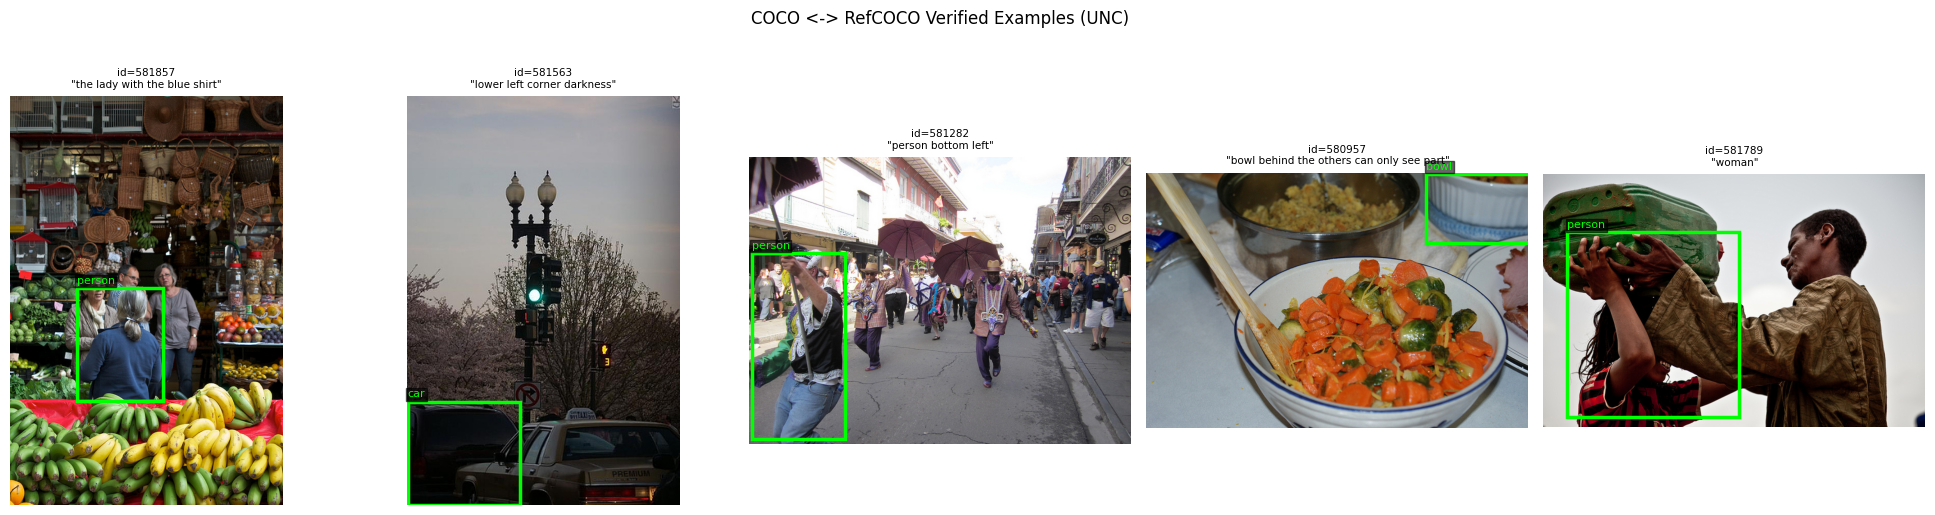

Figure saved -> d:\NLP-Research\module-2\outputs\refcoco_verified_examples.png


In [57]:
# Visualise all 5 verified examples
cols      = len(verification_results)
fig, axes = plt.subplots(1, cols, figsize=(cols * 4, 5))
if cols == 1:
    axes = [axes]

for ax, r in zip(axes, verification_results):
    if not r['coco_img_found']:
        ax.text(0.5, 0.5, 'No image record', ha='center', va='center')
        ax.axis('off')
        continue

    img_path = find_image_on_disk(r['coco_file'], COCO_TRAIN_DIR)
    if img_path is None:
        label = (
            f"image_id={r['image_id']}\nann_id={r['ann_id']}\n"
            f"split={r['split']}\nbbox={r['bbox']}\ncat={r['category']}\n\n"
            f"Expr:\n{r['expressions'][0][:60] if r['expressions'] else '---'}"
        )
        ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=7.5,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
        ax.set_facecolor('#f0f0f0')
    else:
        img_pil = Image.open(img_path).convert('RGB')
        ax.imshow(img_pil)
        if r['bbox_valid']:
            x, y, w, h = r['bbox']
            ax.add_patch(Rectangle((x, y), w, h, linewidth=2.5,
                                   edgecolor='lime', facecolor='none'))
            ax.text(x, y - 6, r['category'], fontsize=8, color='lime',
                    bbox=dict(facecolor='black', alpha=0.6, pad=1))
        expr_str = (r['expressions'][0][:50] if r['expressions'] else '---')
        ax.set_title(f"id={r['image_id']}\n\"{expr_str}\"", fontsize=7.5)
    ax.axis('off')

plt.suptitle('COCO <-> RefCOCO Verified Examples (UNC)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'refcoco_verified_examples.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure saved -> {OUTPUTS_DIR / 'refcoco_verified_examples.png'}")


### 4.2 — Large-Scale Cross-Reference Validation

Run all four checks across every UNC reference to confirm referential integrity at scale.


In [58]:
print('Running large-scale cross-reference validation across all UNC refs ...')

stats = dict(total=0, image_found=0, ann_found=0,
             bbox_valid=0, ann_img_match=0, all_checks_pass=0)

for ref in refs_list_unc:
    image_id = ref.get('image_id')
    ann_id   = ref.get('ann_id')
    stats['total'] += 1

    coco_img = coco_img_lookup.get(image_id)
    coco_ann = coco_ann_lookup.get(ann_id)

    img_ok   = coco_img is not None
    ann_ok   = coco_ann is not None
    bbox     = coco_ann['bbox'] if ann_ok else None
    bbox_ok  = (bbox is not None and len(bbox) == 4
                and all(v >= 0 for v in bbox))
    match_ok = (coco_ann['image_id'] == image_id) if ann_ok else False

    if img_ok:                               stats['image_found']   += 1
    if ann_ok:                               stats['ann_found']     += 1
    if bbox_ok:                              stats['bbox_valid']    += 1
    if match_ok:                             stats['ann_img_match'] += 1
    if img_ok and ann_ok and bbox_ok and match_ok:
        stats['all_checks_pass'] += 1

print()
print('LARGE-SCALE CROSS-REFERENCE VALIDATION — refs(unc).p')
print('=' * 58)
total = stats['total']
for metric, count in stats.items():
    pct = count / total * 100 if total > 0 else 0
    print(f'  {metric:<22} : {count:>7,}  /  {total:,}   ({pct:.2f}%)')


Running large-scale cross-reference validation across all UNC refs ...

LARGE-SCALE CROSS-REFERENCE VALIDATION — refs(unc).p
  total                  :  50,000  /  50,000   (100.00%)
  image_found            :  50,000  /  50,000   (100.00%)
  ann_found              :  50,000  /  50,000   (100.00%)
  bbox_valid             :  50,000  /  50,000   (100.00%)
  ann_img_match          :  50,000  /  50,000   (100.00%)
  all_checks_pass        :  50,000  /  50,000   (100.00%)
